# AI Customer Intelligence & Retention System

## Objective
The goal of this project is to analyze customer behavior, identify patterns, predict churn risk, estimate customer value, and generate actionable recommendations to improve customer retention.

## Dataset
Telco Customer Churn Dataset (IBM)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
sns.set(style="whitegrid")

In [2]:
df=pd.read_excel(r'Telco_customer_churn.xlsx')
df.head(3)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


## Dataset Overview

This dataset contains customer information, services, billing details, and churn status.

We will explore:
- Data structure and types
- Missing values and duplicates
- Distribution of key variables
- Relationships between features and churn

## Data Inspection

In [3]:
df.shape

(7043, 33)

In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## Data Quality Checks

In [7]:
print(df['Total Charges'].dtype)
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors='coerce')
print(df['Total Charges'].dtype)

object
float64


In [8]:
categorical = df.select_dtypes(include='object')
numerical = df.select_dtypes(include=['int64', 'float64'])
categorical.columns

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label', 'Churn Reason'],
      dtype='object')

In [9]:
for x in categorical.columns:
    if categorical[x].dtype=='object':
        print(x,categorical[x].unique())

CustomerID ['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
Country ['United States']
State ['California']
City ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
Lat Long ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
Gender ['Male' 'Female']
Senior Citizen ['No' 'Yes']
Partner ['No' 'Yes']
Dependents ['No' 'Yes']
Phone Service ['Yes' 'No']
Multiple Lines ['No' 'Yes' 'No phone service']
Internet Service ['DSL' 'Fiber optic' 'No']
Online Security ['Yes' 'No' 'No internet service']
Online Backup ['Yes' 'No' 'No internet service']
Device Protection ['No' 'Yes' 'No internet service']
Tech Support ['No' 'Yes' 'No internet service']
Streaming TV ['No' 'Yes' 'No internet service']
Streaming Movies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'Two year' 'One year']
Paperless Billing ['Yes' 

In [10]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [11]:
df.duplicated().sum()

0

## Categorical Feature Analysis

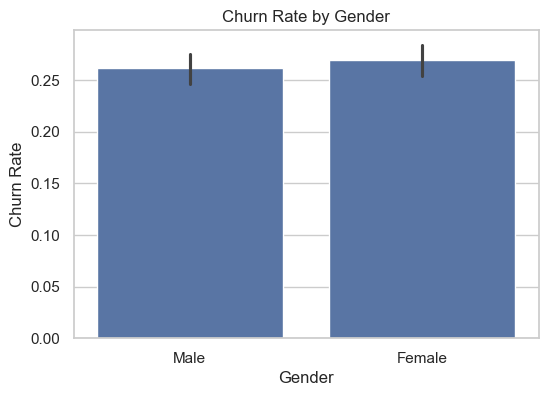

In [12]:
df["Churn"] = df["Churn Label"].map({"Yes": 1, "No": 0})

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Gender", y="Churn")

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.xlabel("Gender")

plt.show()

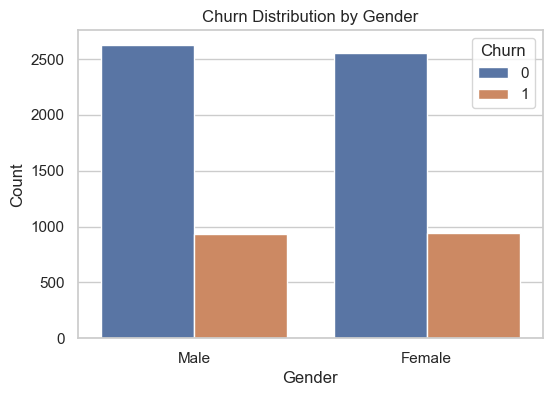

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Churn")

plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

Churn rates are nearly identical across genders, indicating that gender is not a significant factor influencing customer churn.
Customer churn is primarily driven by behavioral and service-related factors rather than demographic attributes.

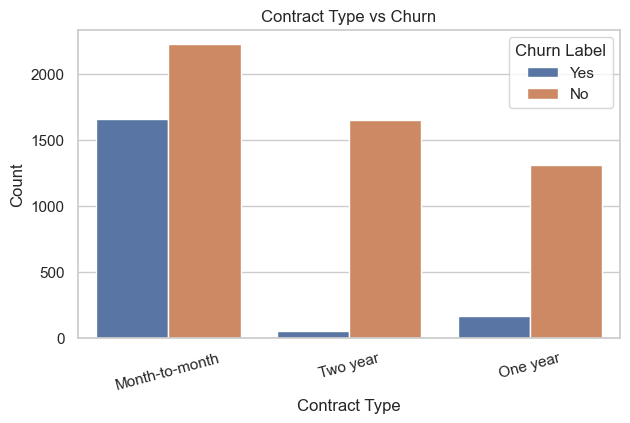

In [14]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

- Churn is heavily concentrated among month-to-month customers, highlighting low commitment as a key risk factor.
- Long-term contracts (especially two-year plans) are highly effective in retaining customers.
- Increasing customer commitment duration can significantly reduce churn rates.
- Retention efforts should prioritize short-term contract customers, where impact is highest.

Customers on month-to-month contracts show significantly higher churn rates compared to those on long-term contracts.
 Encouraging customers to commit to longer contracts can be a highly effective strategy to reduce churn and improve customer retention.

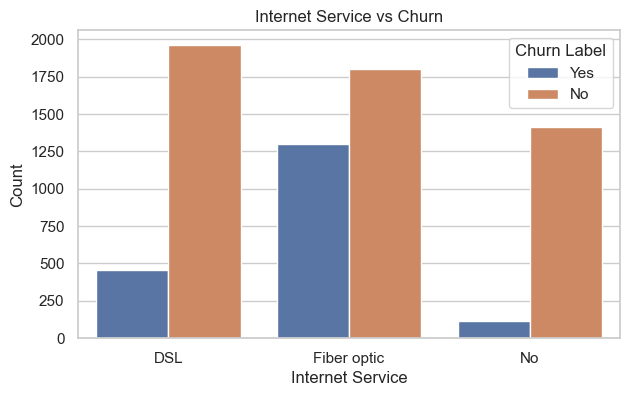

In [15]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Internet Service', hue='Churn Label')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

- Fiber optic users represent the highest churn-risk segment, despite being a premium service group.
- DSL users are more stable, indicating better customer satisfaction or lower expectations.
- Customers without internet services show minimal churn, suggesting lower engagement but also lower risk.
- Improving the experience for fiber optic users could significantly reduce overall churn.

Higher monthly charges are associated with increased churn, indicating potential dissatisfaction with pricing or perceived value. 
Pricing strategies and value communication should be optimized to retain high-paying customers.

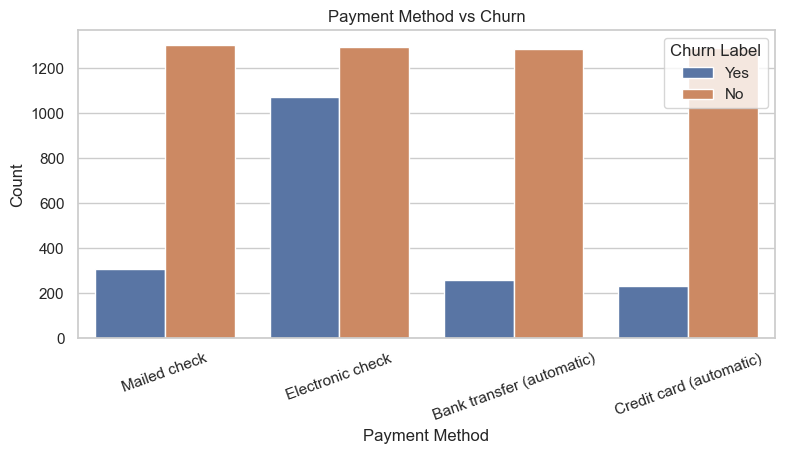

In [16]:
plt.figure(figsize=(9,4))
sns.countplot(data=df, x='Payment Method', hue='Churn Label')
plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

- Electronic check users represent the highest churn-risk group, likely due to lower engagement or payment friction.
- Automatic payment methods strongly improve retention, suggesting convenience plays a key role in customer loyalty.
- Encouraging customers to switch to auto-pay systems could significantly reduce churn

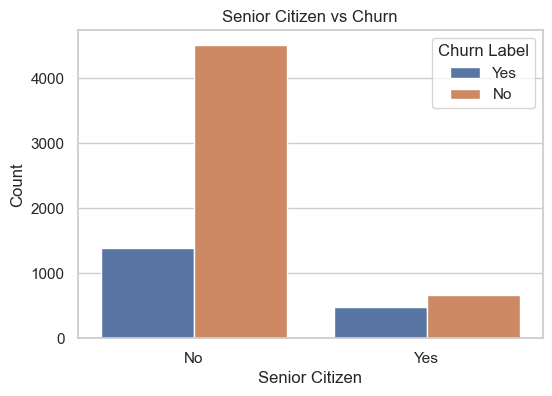

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Senior Citizen', hue='Churn Label')
plt.title('Senior Citizen vs Churn')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')
plt.show()

- Senior citizens represent a higher-risk segment, despite being a smaller portion of the customer base.
- Non-seniors contribute more churn in total volume, but seniors are more likely to churn proportionally.
- Targeted retention strategies for senior customers could reduce churn in a high-risk group.

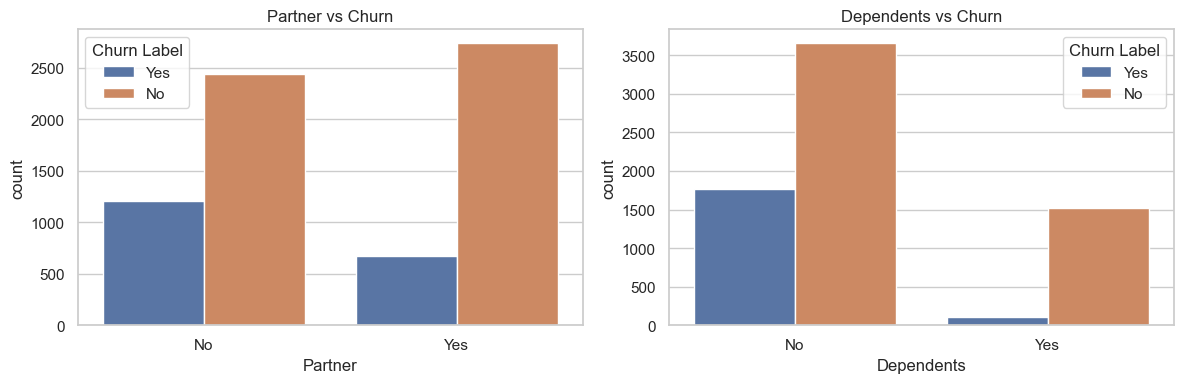

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(data=df, x='Partner', hue='Churn Label', ax=axes[0])
axes[0].set_title('Partner vs Churn')

sns.countplot(data=df, x='Dependents', hue='Churn Label', ax=axes[1])
axes[1].set_title('Dependents vs Churn')

plt.tight_layout()
plt.show()

- Single customers (no partner, no dependents) are more likely to churn, indicating lower attachment to the service.
- Customers with family responsibilities (partner or dependents) show higher retention and stability.
- Family-related factors strongly correlate with reduced churn risk, making them valuable indicators for segmentation.
- Targeting single customers with personalized offers could significantly improve retention rates.

## Numerical Feature Analysis

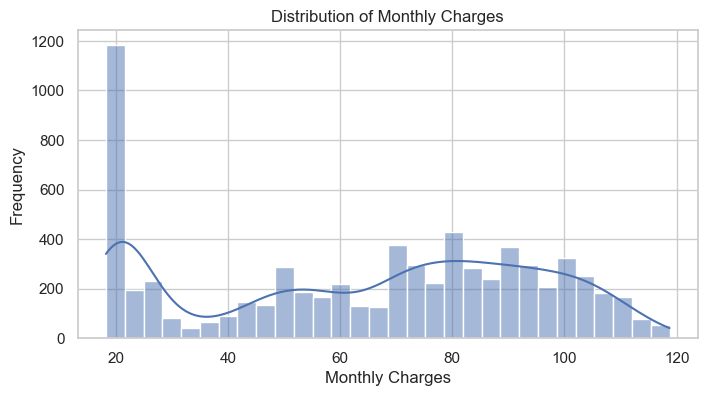

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Monthly Charges', bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

- Customers are clustered into clear pricing tiers (low, medium, high), reflecting different service levels.
- A significant portion of customers pays higher monthly charges, indicating strong adoption of premium services.
- Understanding how churn varies across these pricing segments could unlock key retention opportunities, especially among high-value customers.

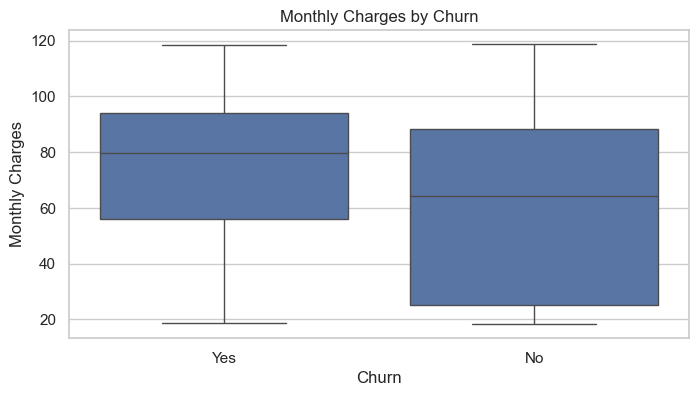

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

- Higher monthly charges are strongly associated with increased churn risk.
- Customers paying more may expect higher value or better service, and unmet expectations could drive churn.
- Pricing strategy and perceived value are critical drivers of customer retention.
- Monitoring high-value customers is essential, as they represent both high revenue and high churn risk.


High-value customers generate more revenue but also exhibit higher churn risk, making them a critical segment for targeted retention strategies.

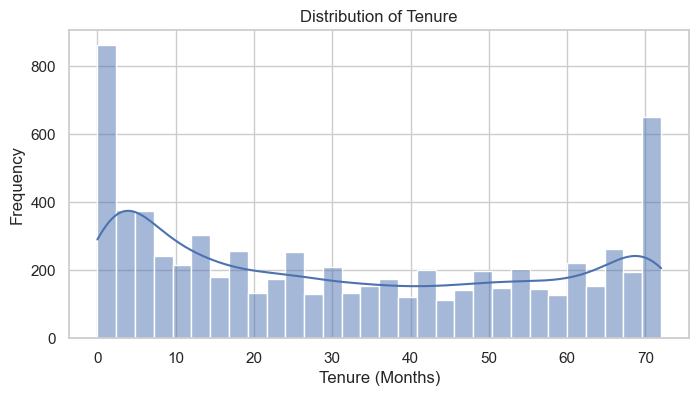

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Tenure Months', bins=30, kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.show()

- The presence of many new customers (low tenure) highlights a segment that may be more vulnerable to churn.
- Long-tenure customers represent a loyal and stable segment, likely contributing to consistent revenue.
- Understanding how churn varies across tenure levels is critical to identifying early-stage churn risk and improving retention strategies.

Customer tenure shows a clear split between new and long-term users, suggesting that early customer experience may play a critical role in retention.

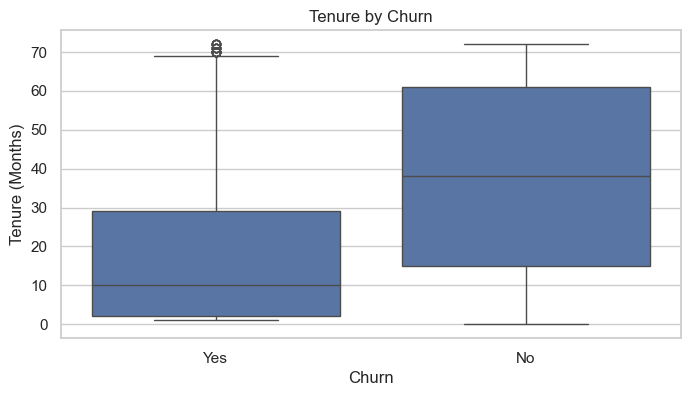

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Churn Label', y='Tenure Months')
plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

- Churn is heavily concentrated among new customers, highlighting the importance of early customer experience.
- Long-tenure customers are significantly more stable, indicating strong retention once customers pass the initial stages.
- Improving onboarding and early engagement strategies could substantially reduce overall churn.

Customers are most likely to churn in the early stages of their lifecycle, making the first months critical for retention.

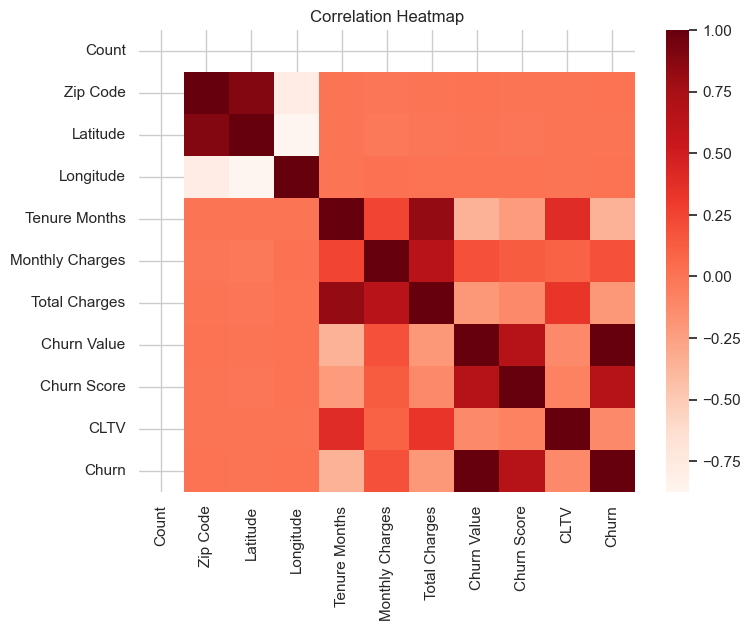

In [23]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), cmap='Reds', annot=False)
plt.title('Correlation Heatmap')
plt.show()

- Customer tenure is the strongest protective factor against churn, highlighting the importance of early retention.
- Higher monthly charges increase churn risk, indicating a potential gap between price and perceived value.
- Long-term customers contribute significantly to higher lifetime value, making retention a key revenue driver.
- Churn is driven more by behavioral and financial factors rather than geographic location.

Customer behavior (tenure and spending) is far more predictive of churn than geographic factors, emphasizing the importance of engagement and value delivery

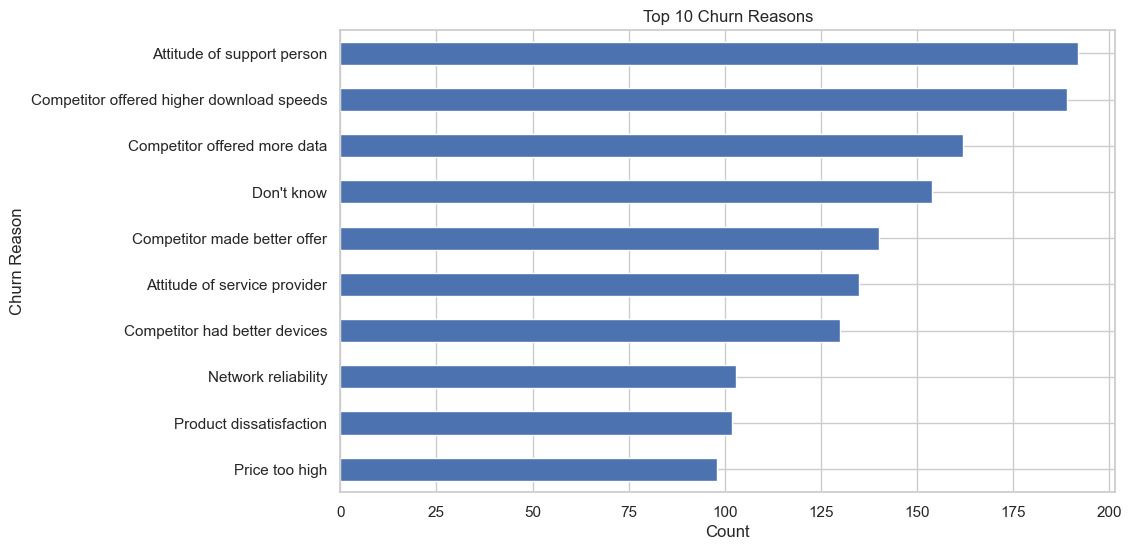

In [24]:
churned = df[df['Churn Label'] == 'Yes']

plt.figure(figsize=(10,6))
churned['Churn Reason'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Churn Reasons')
plt.xlabel('Count')
plt.ylabel('Churn Reason')
plt.gca().invert_yaxis()
plt.show()

- Customer experience is the leading driver of churn, even more than pricing.
- Competitors are successfully attracting customers through better value propositions, especially in speed and data offerings.
- The presence of many unclear churn reasons ("Don’t know") suggests gaps in customer feedback collection.
- Improving customer support and service quality could significantly reduce churn at scale.

Customer experience and competitive offerings are the primary drivers of churn, outweighing even price-related factors.

Churn  Reason is useful for descriptive analysis, but it will not be used as a model feature because it is only known after churn occurs.

In [25]:
df["Churn"] = df["Churn Label"].map({"Yes": 1, "No": 0})
df.drop(["Churn Label", "Churn Value"], axis=1, inplace=True)

In [26]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Churn Distribution

The dataset contains 7043 customers:
- 73% of customers stayed
- 27% of customers churned

**This indicates a moderately imbalanced dataset.**

For churn prediction, most customers staying and a smaller portion churning. This is important for modeling because accuracy alone may be misleading. Later, recall and F1-score should be emphasized when evaluating churn models.

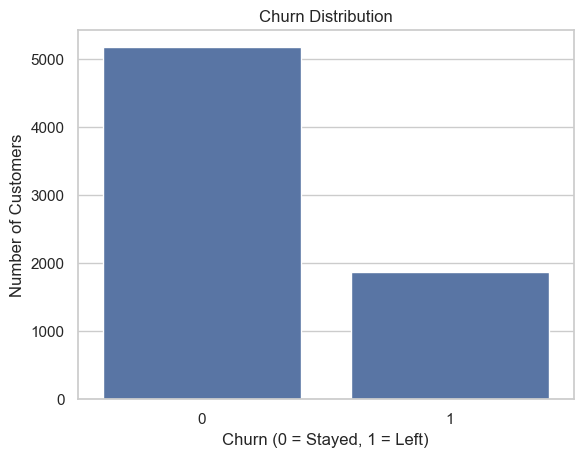

In [27]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")
plt.show()

- While most customers remain, churn affects a considerable segment of the customer base, impacting revenue and growth.
- The imbalance suggests predictive models should be carefully evaluated (e.g., precision/recall) to avoid bias toward the majority class.
- Reducing churn even slightly could lead to significant revenue gains, given the volume of affected customers.

Although the majority of customers are retained, churn represents a significant and actionable business challenge.

## Key Findings from Data Understanding


- Customer churn is primarily driven by low commitment and early-stage disengagement.
Customers on month-to-month contracts and those with low tenure are significantly more likely to churn, highlighting the critical importance of the early customer lifecycle.
- High-value customers are at greater risk of churn.
Customers with higher monthly charges tend to leave more frequently, suggesting a gap between pricing and perceived value.
- Customer experience is the strongest churn driver.
Poor interactions with support staff and service providers are the leading reasons for churn, outweighing even pricing concerns.
- Competitive pressure plays a major role in customer loss.
Many customers leave due to better offers from competitors, particularly in terms of speed, data, and overall value.
- Behavioral patterns strongly predict churn.
Payment method, contract type, and tenure are key indicators, with electronic check users and short-term customers showing the highest risk.
- Customer stability increases with commitment and integration.
Customers with long-term contracts, automatic payments, and family ties (partners/dependents) are significantly more likely to stay.

## Next Step

Based on these insights, the next phase will focus on:
- Data cleaning and feature engineering